# Manual Labeling Preparation (Label Studio)

This notebook prepares real ERP data for manual classification in Label Studio.

Classes:
- sigmoid
- one_sided_fan
- two_sided_fan
- diverging_bar
- hourglass
- tilted_bar
- no_class

References:
- https://github.com/s-ccs/ERPgnostics.jl/tree/main/examples
- `data_vis.ipynb` (loading/preprocessing logic)
- HDF5.jl: https://juliaio.github.io/HDF5.jl/stable/
- CSV.jl: https://csv.juliadata.org/stable/index.html
- DataFrames.jl: https://dataframes.juliadata.org/stable/
- CairoMakie: https://docs.makie.org/stable/explanations/backends/backends.html
- Label Studio Tasks JSON: https://labelstud.io/guide/tasks


In [1]:
import Pkg
Pkg.activate(".")

using Random, CSV, DataFrames, HDF5, JLD2, Statistics, StatsBase, Printf, Normalization
using CairoMakie
using ImageFiltering: imfilter, KernelFactors


  Activating project at `~/Dokumente/BA2/notebooks/model_test`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
┌ Warning: attempting to remove probably stale pidfile
│   path = "/home/benjamin/.julia/compiled/v1.12/PrecompileTools/AQ9Mk_aAiQW.ji.pidfile"
└ @ FileWatching.Pidfile /usr/share/julia/stdlib/v1.12/FileWatching/src/pidfile.jl:247

In [2]:
# Load all data sources
data_dir = joinpath(pwd(), "real_data_sets", "fixations_dataset")

# ERP data (channels x time x trials)
erps = h5open(joinpath(data_dir, "data_fixations.hdf5"), "r") do fid
    read(fid["data"]["data_fixations.hdf5"])
end

# Events
events = CSV.read(joinpath(data_dir, "events.csv"), DataFrame)
evts_d = CSV.read(joinpath(data_dir, "evts_d.csv"), DataFrame)
evts_mf = CSV.read(joinpath(data_dir, "evts_mf.csv"), DataFrame)

# Positions
positions = JLD2.load(joinpath(data_dir, "positions_128.jld2"))

# Epoching Parameter
sampling_rate = 512
pre_stim_s = 0.5
pre_samples = Int(round(pre_stim_s * sampling_rate))
time_zero_idx = pre_samples + 1

println("ERP shape: ", size(erps))
println("Events rows: ", nrow(events))
println("Events rows (evts_d): ", nrow(evts_d))
println("Events rows (evts_mf): ", nrow(evts_mf))
println("Available sort variables: ", propertynames(events))


ERP shape: (128, 769, 2508)
Events rows: 2508
Events rows (evts_d): 128
Events rows (evts_mf): 128
Available sort variables: [:duration, :sac_amplitude, :sac_endpos_x, :sac_endpos_y, :sac_startpos_x, :sac_startpos_y, :sac_vmax, :fix_avgpos_x, :fix_avgpos_y, :fix_avgpupilsize, :overlapping, :fix_samebox, :id, :picID, :trialnum, :fix_type, :onset, :stim_set, :stim_file, :latency]


In [3]:
# Core helpers reused from data_vis.ipynb
const FILTER_BORDER = "reflect"
const LOWPASS_SIGMA = 75.0f0
const LOWPASS_KERNEL_SIZE = (21, 21)

include(joinpath(pwd(), "..", "utils", "erp_image_utils.jl"))
using .ERPImageUtils: gaussian_kernel, zscore_timepoints

function sortvalues_from(df::DataFrame, col::Symbol)
    v = df[!, col]
    if eltype(v) <: Number
        return Float64.(v)
    end
    return collect(v)
end

function process_erp_timed(erps, events::DataFrame, channel::Int, sort_col::Symbol, time_zero_idx::Int;
                           low_pass_factor::Real = LOWPASS_SIGMA)
    @assert 1 <= channel <= size(erps, 1) "channel out of range"
    @assert sort_col in propertynames(events) "sort column not found: $(sort_col)"

    # 1) Extract post-stimulus matrix (time x trials)
    t_extract0 = time_ns()
    data = Float32.(erps[channel, time_zero_idx:end, :])
    n = min(size(data, 2), nrow(events))
    data = data[:, 1:n]
    events_n = events[1:n, :]
    t_extract_prepare = (time_ns() - t_extract0) / 1e9

    # 2) Sort by sort variable
    t_sort0 = time_ns()
    sortvals = sortvalues_from(events_n, sort_col)
    order = sortperm(sortvals)
    data_sorted = data[:, order]
    t_sort = (time_ns() - t_sort0) / 1e9

    # 3) Z-score per timepoint across trials
    t_z0 = time_ns()
    data_z = zscore_timepoints(data_sorted)
    t_zscore = (time_ns() - t_z0) / 1e9

    # 4) Convert to trials x time image
    t_to_img0 = time_ns()
    img_trials_time = Float32.(permutedims(data_z, (2, 1)))
    t_to_trials_time = (time_ns() - t_to_img0) / 1e9

    # 5) Optional low-pass in original resolution
    t_lp0 = time_ns()
    if low_pass_factor > 0
        kernel = gaussian_kernel(low_pass_factor, size(img_trials_time), size(img_trials_time), LOWPASS_KERNEL_SIZE)
        img_trials_time = Float32.(imfilter(img_trials_time, kernel, FILTER_BORDER))
    end
    t_low_pass = (time_ns() - t_lp0) / 1e9

    stage_times = (
        extract_prepare = t_extract_prepare,
        sort = t_sort,
        zscore = t_zscore,
        to_trials_time = t_to_trials_time,
        low_pass = t_low_pass,
    )

    return img_trials_time, stage_times
end

function process_erp(erps, events::DataFrame, channel::Int, sort_col::Symbol, time_zero_idx::Int;
                     low_pass_factor::Real = LOWPASS_SIGMA)
    img, _ = process_erp_timed(erps, events, channel, sort_col, time_zero_idx; low_pass_factor = low_pass_factor)
    return img
end

function generate_selections(n_channels::Int, sort_vars::Vector{Symbol};
                             target_count::Int = 100, max_count::Int = 110)
    target_count = clamp(target_count, 100, max_count)
    n_sort_vars = length(sort_vars)

    selections = NamedTuple{(:channel, :sort_var), Tuple{Int, Symbol}}[]
    img_count = 0
    ch = 1

    while img_count < target_count && img_count < max_count && ch <= n_channels
        sort_idx = mod1(img_count + 1, n_sort_vars)
        sort_var = sort_vars[sort_idx]

        push!(selections, (channel = ch, sort_var = sort_var))
        img_count += 1

        # Skip one channel after each full sort-variable rotation.
        ch += (mod(img_count, n_sort_vars) == 0) ? 2 : 1
    end

    return selections
end

function fmt_tick(v)
    v3 = round(Float64(v), digits = 3)
    iszero(v3) && return "0"
    s = @sprintf("%.3f", v3)
    return replace(s, r"\.?0+$" => "")
end

function symmetric_abs99_range(img::AbstractMatrix{<:Real})
    vmax = max(Float32(quantile(vec(abs.(Float32.(img))), 0.99)), eps(Float32))
    return -vmax, vmax
end

function plot_erp_grid(images, metadata; n_cols = 5)
    n_images = length(images)
    n_rows = cld(n_images, n_cols)

    panel_px = 320
    cb_px = 62
    row_px = 400
    cb_height_rel = panel_px / row_px

    fig = Figure(size = ((panel_px + cb_px + 34) * n_cols, row_px * n_rows), figure_padding = 24)

    for (idx, (img, meta)) in enumerate(zip(images, metadata))
        row = cld(idx, n_cols)
        col = mod1(idx, n_cols)

        vmin, vmax = symmetric_abs99_range(img)
        n_trials, n_time = size(img)
        x_first, x_mid, x_last = 1, Int(round((n_time + 1) / 2)), n_time
        y_first, y_mid, y_last = 1, Int(round((n_trials + 1) / 2)), n_trials

        img_col = 2 * col - 1
        cb_col = 2 * col

        title = "ch$(meta.channel) | $(meta.sort_variable)"

        ax = Axis(fig[row, img_col];
            title = title,
            titlesize = 24,
            xlabel = "time",
            ylabel = "trials",
            xlabelsize = 22,
            ylabelsize = 22,
            xticklabelsize = 18,
            yticklabelsize = 18,
            aspect = AxisAspect(1),
        )
        ax.xticks = ([x_first, x_mid, x_last], [string(x_first), string(x_mid), string(x_last)])
        ax.yticks = ([y_first, y_mid, y_last], [string(y_first), string(y_mid), string(y_last)])

        hm = heatmap!(
            ax,
            1:n_time,
            1:n_trials,
            permutedims(Float32.(img), (2, 1));
            colormap = :balance,
            colorrange = (vmin, vmax),
        )

        cb_ticks = ([vmin, 0f0, vmax], [fmt_tick(vmin), "0", fmt_tick(vmax)])

        Colorbar(fig[row, cb_col], hm;
            width = 20,
            height = Relative(cb_height_rel),
            valign = :center,
            ticklabelsize = 18,
            ticks = cb_ticks,
        )

        rowsize!(fig.layout, row, Fixed(row_px))
        colsize!(fig.layout, img_col, Fixed(panel_px))
        colsize!(fig.layout, cb_col, Fixed(cb_px))
    end

    colgap!(fig.layout, 12)
    rowgap!(fig.layout, 16)
    resize_to_layout!(fig)
    return fig
end

# No data export in this notebook revision.



plot_erp_grid (generic function with 1 method)

In [4]:
sort_vars = [:duration, :sac_amplitude, :fix_avgpos_x, :fix_avgpupilsize, :fix_type, :latency]

missing_cols = setdiff(sort_vars, propertynames(events))
if !isempty(missing_cols)
    error("Missing sort variables in events.csv: $(missing_cols)")
end

n_channels = size(erps, 1)
selections = generate_selections(n_channels, sort_vars; target_count = 100)

println("Generated selection: ", length(selections), " images")
println("First 12 selections:")
for s in selections[1:min(end, 12)]
    println("  ", s)
end


Generated selection: 100 images
First 12 selections:
  (channel = 1, sort_var = :duration)
  (channel = 2, sort_var = :sac_amplitude)
  (channel = 3, sort_var = :fix_avgpos_x)
  (channel = 4, sort_var = :fix_avgpupilsize)
  (channel = 5, sort_var = :fix_type)
  (channel = 6, sort_var = :latency)
  (channel = 8, sort_var = :duration)
  (channel = 9, sort_var = :sac_amplitude)
  (channel = 10, sort_var = :fix_avgpos_x)
  (channel = 11, sort_var = :fix_avgpupilsize)
  (channel = 12, sort_var = :fix_type)
  (channel = 13, sort_var = :latency)


In [5]:
images = Matrix{Float32}[]
metadata_list = NamedTuple[]

first_plot_stage_order = [:extract_prepare, :sort, :zscore, :to_trials_time, :low_pass]
first_plot_stage_totals = Dict(stage => 0.0 for stage in first_plot_stage_order)

first_plot_started = time_ns()

for (idx, sel) in enumerate(selections)
    img, stage_times = process_erp_timed(erps, events, sel.channel, sel.sort_var, time_zero_idx)

    meta = (
        id = idx,
        channel = sel.channel,
        sort_variable = sel.sort_var,
        n_trials = size(img, 1),
        n_timepoints = size(img, 2),
        sampling_rate = sampling_rate,
        source_file = "data_fixations.hdf5",
    )

    push!(images, img)
    push!(metadata_list, meta)

    for stage in first_plot_stage_order
        first_plot_stage_totals[stage] += getproperty(stage_times, stage)
    end
end

first_plot_total_s = (time_ns() - first_plot_started) / 1e9
first_plot_stages_total_s = sum(values(first_plot_stage_totals))
first_plot_overhead_s = max(first_plot_total_s - first_plot_stages_total_s, 0.0)

timing_rows_first = NamedTuple[]
calls_first = length(images)
for stage in first_plot_stage_order
    total_s = first_plot_stage_totals[stage]
    avg_ms = calls_first == 0 ? 0.0 : 1000.0 * total_s / calls_first
    pct = first_plot_stages_total_s == 0 ? 0.0 : 100.0 * total_s / first_plot_stages_total_s
    push!(timing_rows_first, (
        stage = String(stage),
        calls = calls_first,
        total_s = total_s,
        avg_ms = avg_ms,
        pct_time = pct,
    ))
end

first_plot_timing_df = DataFrame(timing_rows_first)
first_plot_timing_df.total_s = round.(first_plot_timing_df.total_s, digits = 4)
first_plot_timing_df.avg_ms = round.(first_plot_timing_df.avg_ms, digits = 3)
first_plot_timing_df.pct_time = round.(first_plot_timing_df.pct_time, digits = 2)

println("Processed (first overview plot pipeline): ", length(images), " images")
println("Processing order: extract_prepare -> sort -> zscore -> to_trials_time -> low_pass")
println(@sprintf("Total wall time (without plotting): %.3f s", first_plot_total_s))
println(@sprintf("Measured stage time sum: %.3f s", first_plot_stages_total_s))
println(@sprintf("Loop/metadata overhead: %.3f s", first_plot_overhead_s))
println("Stage timing summary (processing order):")
show(first_plot_timing_df, allrows = true, allcols = true)
println()

println("Example metadata: ", first(metadata_list))



Processed (first overview plot pipeline): 100 images
Processing order: extract_prepare -> sort -> zscore -> to_trials_time -> low_pass
Total wall time (without plotting): 3.399 s
Measured stage time sum: 2.942 s
Loop/metadata overhead: 0.457 s
Stage timing summary (processing order):
5×5 DataFrame
 Row │ stage            calls  total_s  avg_ms   pct_time 
     │ String           Int64  Float64  Float64  Float64  
─────┼────────────────────────────────────────────────────
   1 │ extract_prepare    100   0.8361    8.361     28.42
   2 │ sort               100   0.2004    2.004      6.81
   3 │ zscore             100   1.0918   10.918     37.11
   4 │ to_trials_time     100   0.2713    2.713      9.22
   5 │ low_pass           100   0.5424    5.424     18.44
Example metadata: (id = 1, channel = 1, sort_variable = :duration, n_trials = 2508, n_timepoints = 513, sampling_rate = 512, source_file = "data_fixations.hdf5")


In [6]:
# Data export is intentionally disabled in this notebook revision.
# Keep this notebook focused on visualization-only output.


In [7]:
# No test export cell in this revision.
# If export is needed later, add a separate dedicated notebook/script.


In [8]:
# # Export 100 non-resized ERP images (first overview pipeline) for Label Studio.
# # Each exported image contains its own colorbar and title with channel + sort variable.

# if !@isdefined(images) || !@isdefined(metadata_list)
#     error("Run the first overview processing cell before export.")
# end

# if length(images) != length(metadata_list)
#     error("images and metadata_list length mismatch.")
# end

# export_count = min(100, length(images))

# notebook_dir = isfile(joinpath(pwd(), "manual_labeling_prepare.ipynb")) ? pwd() : joinpath(pwd(), "notebooks", "model_test")
# export_root = joinpath(notebook_dir, "label_studio_data_unlabelled")
# images_dir = joinpath(export_root, "images")
# mkpath(images_dir)

# function sanitize_slug(x)
#     return replace(string(x), r"[^A-Za-z0-9_-]" => "_")
# end

# # Per-image rendering settings (same visual family as the first overview plot)
# panel_px = 320
# cb_px = 62
# row_px = 400
# cb_height_rel = panel_px / row_px

# manifest_rows = NamedTuple[]

# t_start_export = time_ns()

# for i in 1:export_count
#     img = images[i]
#     meta = metadata_list[i]

#     vmin, vmax = symmetric_abs99_range(img)
#     n_trials, n_time = size(img)

#     x_first, x_mid, x_last = 1, Int(round((n_time + 1) / 2)), n_time
#     y_first, y_mid, y_last = 1, Int(round((n_trials + 1) / 2)), n_trials

#     sort_slug = sanitize_slug(meta.sort_variable)
#     filename = @sprintf("erp_%03d_ch%03d_%s.png", i, Int(meta.channel), sort_slug)
#     output_path = joinpath(images_dir, filename)

#     fig = Figure(size = (panel_px + cb_px + 34, row_px), figure_padding = 24)

#     ax = Axis(fig[1, 1];
#         title = "ch$(meta.channel) | $(meta.sort_variable)",
#         titlesize = 24,
#         xlabel = "time",
#         ylabel = "trials",
#         xlabelsize = 22,
#         ylabelsize = 22,
#         xticklabelsize = 18,
#         yticklabelsize = 18,
#         aspect = AxisAspect(1),
#     )
#     ax.xticks = ([x_first, x_mid, x_last], [string(x_first), string(x_mid), string(x_last)])
#     ax.yticks = ([y_first, y_mid, y_last], [string(y_first), string(y_mid), string(y_last)])

#     hm = heatmap!(
#         ax,
#         1:n_time,
#         1:n_trials,
#         permutedims(Float32.(img), (2, 1));
#         colormap = :balance,
#         colorrange = (vmin, vmax),
#     )

#     cb_ticks = ([vmin, 0f0, vmax], [fmt_tick(vmin), "0", fmt_tick(vmax)])

#     Colorbar(fig[1, 2], hm;
#         width = 20,
#         height = Relative(cb_height_rel),
#         valign = :center,
#         ticklabelsize = 18,
#         ticks = cb_ticks,
#     )

#     colsize!(fig.layout, 1, Fixed(panel_px))
#     colsize!(fig.layout, 2, Fixed(cb_px))
#     rowsize!(fig.layout, 1, Fixed(row_px))
#     colgap!(fig.layout, 12)
#     resize_to_layout!(fig)

#     CairoMakie.save(output_path, fig)

#     local_file_rel = joinpath("label_studio_data_unlabelled", "images", filename)
#     local_file_rel = replace(local_file_rel, '\\' => "/")

#     push!(manifest_rows, (
#         id = Int(meta.id),
#         image = "/data/local-files/?d=$(local_file_rel)",
#         channel = Int(meta.channel),
#         sort_variable = string(meta.sort_variable),
#         n_trials = Int(meta.n_trials),
#         n_timepoints = Int(meta.n_timepoints),
#         sampling_rate = Int(meta.sampling_rate),
#         source_file = string(meta.source_file),
#         image_file = filename,
#     ))
# end

# export_elapsed_s = (time_ns() - t_start_export) / 1e9

# manifest_df = DataFrame(manifest_rows)
# csv_manifest_path = joinpath(export_root, "tasks_unlabelled_100.csv")
# CSV.write(csv_manifest_path, manifest_df)

# json_manifest_path = joinpath(export_root, "tasks_unlabelled_100.json")
# if Base.find_package("JSON3") === nothing
#     import Pkg
#     println("JSON3 not found, installing JSON3 for task JSON export...")
#     Pkg.add("JSON3")
# end
# import JSON3

# tasks = [
#     Dict(
#         "id" => Int(r.id),
#         "data" => Dict(
#             "image" => String(r.image),
#             "channel" => Int(r.channel),
#             "sort_variable" => String(r.sort_variable),
#             "n_trials" => Int(r.n_trials),
#             "n_timepoints" => Int(r.n_timepoints),
#             "sampling_rate" => Int(r.sampling_rate),
#             "source_file" => String(r.source_file),
#             "image_file" => String(r.image_file),
#         ),
#     ) for r in eachrow(manifest_df)
# ]
# open(json_manifest_path, "w") do io
#     JSON3.pretty(io, tasks)
# end
# println("JSON manifest: ", json_manifest_path)

# println("Exported ", export_count, " images to: ", images_dir)
# println("CSV manifest: ", csv_manifest_path)
# println(@sprintf("Export time: %.3f s", export_elapsed_s))
# println("Note: For Local Files in Label Studio, set LOCAL_FILES_DOCUMENT_ROOT to: ", notebook_dir)





Generated additional disjoint images: 400
Distribution over sort variables:
6×2 DataFrame
 Row │ sort_variable     count 
     │ String            Int64 
─────┼─────────────────────────
   1 │ duration             67
   2 │ fix_avgpos_x         67
   3 │ fix_avgpupilsize     67
   4 │ fix_type             66
   5 │ latency              66
   6 │ sac_amplitude        67
Preview indices from additional set: [1, 150, 250, 400]


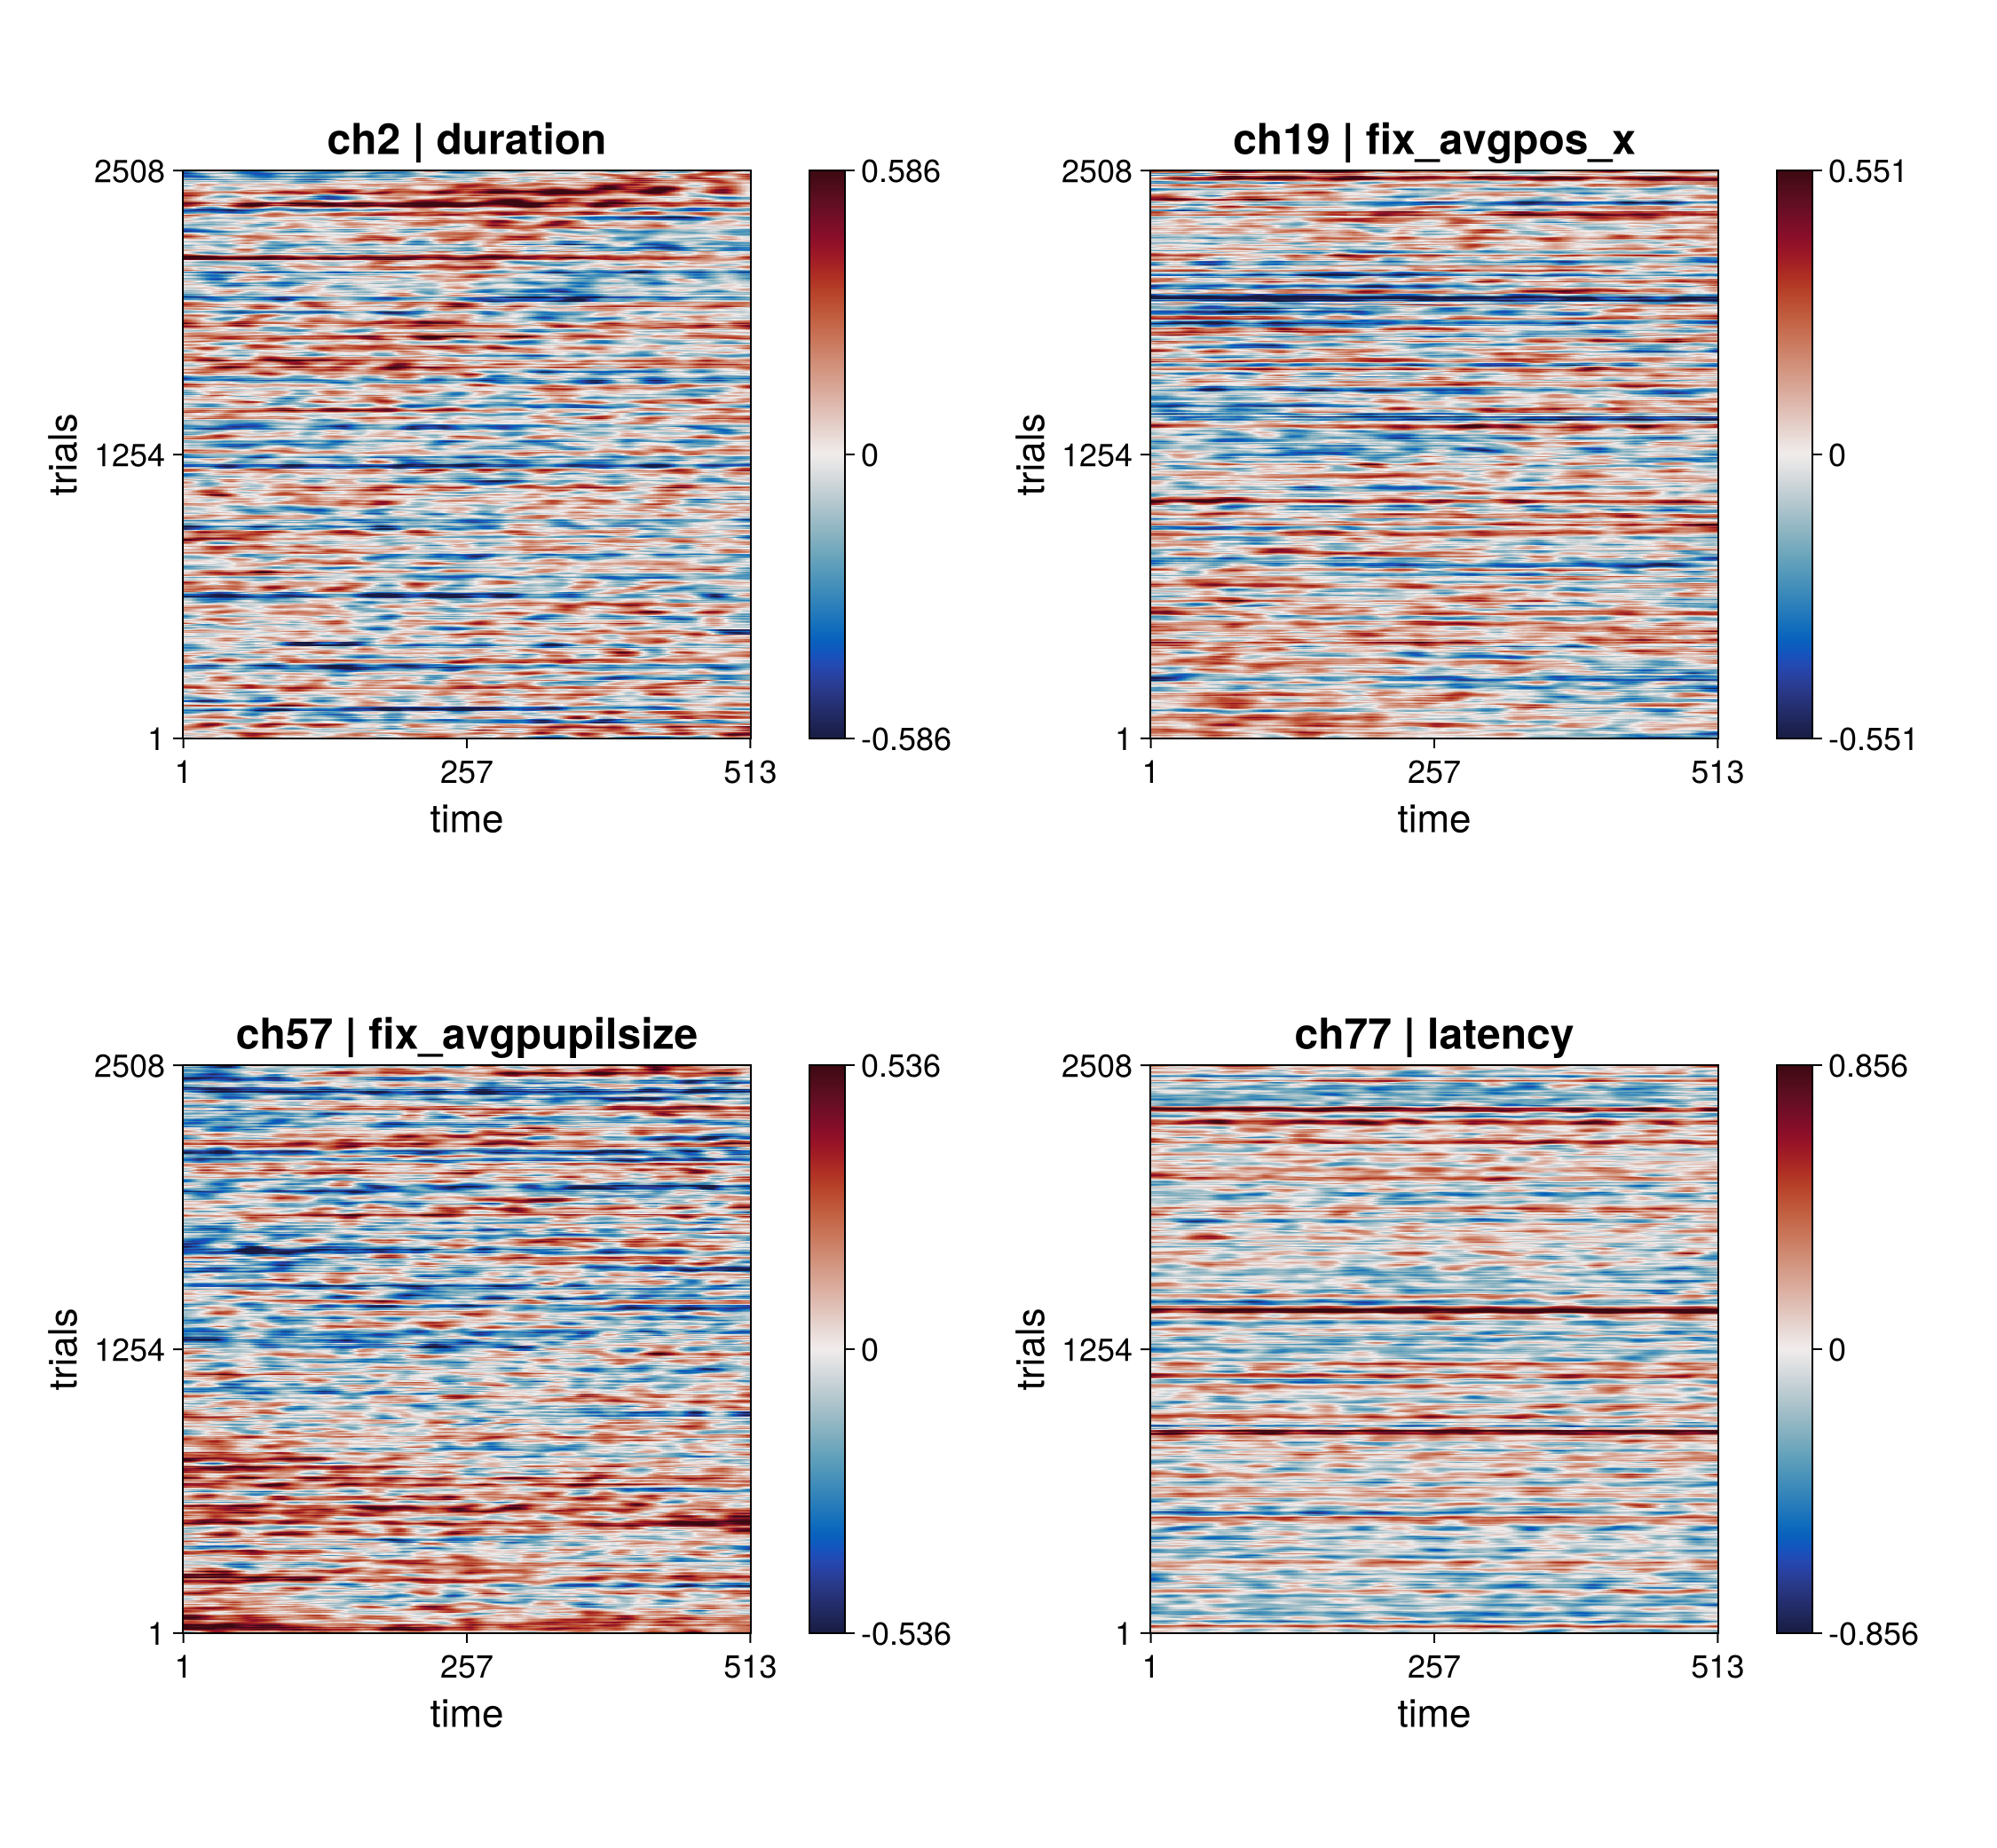


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Additional export done.
Images dir: /home/benjamin/Dokumente/BA2/notebooks/model_test/label_studio_data_unlabelled_additional_400/images
CSV manifest: /home/benjamin/Dokumente/BA2/notebooks/model_test/label_studio_data_unlabelled_additional_400/tasks_unlabelled_400.csv
JSON manifest: /home/benjamin/Dokumente/BA2/notebooks/model_test/label_studio_data_unlabelled_additional_400/tasks_unlabelled_400.json
Export time (additional 400): 26.099 s
Local-files root reminder: /home/benjamin/Dokumente/BA2/notebooks/model_test


In [9]:
# Export 400 additional non-resized ERP images with empty intersection to the first 100.
# Same schema: balanced over sort variables, same preprocessing pipeline as above.
# Also show a small preview plot for indices: 1, 150, 250, last.

if !@isdefined(images) || !@isdefined(metadata_list)
    error("Run the first overview processing cells before this additional export cell.")
end

base_export_count = 100
if length(metadata_list) < base_export_count
    error("Need at least 100 base items in metadata_list, got $(length(metadata_list)).")
end

function generate_disjoint_additional_selections(base_metadata, sort_vars::Vector{Symbol}, n_channels::Int; additional_count::Int = 400)
    n_sort = length(sort_vars)
    @assert n_sort > 0 "sort_vars must not be empty"

    used_pairs = Set{Tuple{Int, Symbol}}()
    for m in base_metadata
        push!(used_pairs, (Int(m.channel), Symbol(m.sort_variable)))
    end

    # Balanced allocation per sort variable (same schema: evenly distributed).
    base_per_sort = fld(additional_count, n_sort)
    rem_per_sort = additional_count - base_per_sort * n_sort

    selections_out = NamedTuple{(:channel, :sort_var), Tuple{Int, Symbol}}[]

    for (i, sv) in enumerate(sort_vars)
        need = base_per_sort + (i <= rem_per_sort ? 1 : 0)
        available_channels = [ch for ch in 1:n_channels if !((ch, sv) in used_pairs)]

        if length(available_channels) < need
            error("Not enough disjoint pairs for sort_var=$(sv). Need $(need), have $(length(available_channels)).")
        end

        for ch in available_channels[1:need]
            push!(selections_out, (channel = ch, sort_var = sv))
            push!(used_pairs, (ch, sv))
        end
    end

    @assert length(selections_out) == additional_count "Internal error: additional selection size mismatch."
    return selections_out
end

function sanitize_slug_additional(x)
    return replace(string(x), r"[^A-Za-z0-9_-]" => "_")
end

# Build disjoint additional selections
base_metadata = metadata_list[1:base_export_count]
base_pairs = Set((Int(m.channel), Symbol(m.sort_variable)) for m in base_metadata)

n_channels = size(erps, 1)
additional_count = 400
selections_additional_400 = generate_disjoint_additional_selections(base_metadata, sort_vars, n_channels; additional_count = additional_count)

additional_pairs = Set((s.channel, s.sort_var) for s in selections_additional_400)
overlap_pairs = intersect(base_pairs, additional_pairs)
@assert isempty(overlap_pairs) "Additional set overlaps with the first 100 base pairs."

# Process additional ERP images (same preprocessing pipeline)
images_additional_400 = Matrix{Float32}[]
metadata_additional_400 = NamedTuple[]

for (idx, sel) in enumerate(selections_additional_400)
    img, _ = process_erp_timed(erps, events, sel.channel, sel.sort_var, time_zero_idx)

    meta = (
        id = idx,
        channel = sel.channel,
        sort_variable = sel.sort_var,
        n_trials = size(img, 1),
        n_timepoints = size(img, 2),
        sampling_rate = sampling_rate,
        source_file = "data_fixations.hdf5",
    )

    push!(images_additional_400, img)
    push!(metadata_additional_400, meta)
end

println("Generated additional disjoint images: ", length(images_additional_400))

dist_df = combine(groupby(DataFrame(sort_variable = String.(getfield.(selections_additional_400, :sort_var))), :sort_variable), nrow => :count)
sort!(dist_df, :sort_variable)
println("Distribution over sort variables:")
show(dist_df, allrows = true, allcols = true)
println()

# Preview plot: first, 150, 250, last
preview_indices = Int[]
for raw_idx in (1, 150, 250, length(images_additional_400))
    idx = clamp(raw_idx, 1, length(images_additional_400))
    if !(idx in preview_indices)
        push!(preview_indices, idx)
    end
end

preview_images = [images_additional_400[i] for i in preview_indices]
preview_meta = [metadata_additional_400[i] for i in preview_indices]

fig_additional_preview = plot_erp_grid(preview_images, preview_meta; n_cols = 2)
println("Preview indices from additional set: ", preview_indices)
display(fig_additional_preview)

# Export additional set for Label Studio
notebook_dir = isfile(joinpath(pwd(), "manual_labeling_prepare.ipynb")) ? pwd() : joinpath(pwd(), "notebooks", "model_test")
export_root_additional = joinpath(notebook_dir, "label_studio_data_unlabelled_additional_400")
images_dir_additional = joinpath(export_root_additional, "images")
mkpath(images_dir_additional)

panel_px = 320
cb_px = 62
row_px = 400
cb_height_rel = panel_px / row_px

manifest_rows_additional = NamedTuple[]

t_start_export_additional = time_ns()

for i in 1:length(images_additional_400)
    img = images_additional_400[i]
    meta = metadata_additional_400[i]

    vmin, vmax = symmetric_abs99_range(img)
    n_trials, n_time = size(img)

    x_first, x_mid, x_last = 1, Int(round((n_time + 1) / 2)), n_time
    y_first, y_mid, y_last = 1, Int(round((n_trials + 1) / 2)), n_trials

    sort_slug = sanitize_slug_additional(meta.sort_variable)
    filename = @sprintf("erp_additional_%03d_ch%03d_%s.png", i, Int(meta.channel), sort_slug)
    output_path = joinpath(images_dir_additional, filename)

    fig = Figure(size = (panel_px + cb_px + 34, row_px), figure_padding = 24)

    ax = Axis(fig[1, 1];
        title = "ch$(meta.channel) | $(meta.sort_variable)",
        titlesize = 24,
        xlabel = "time",
        ylabel = "trials",
        xlabelsize = 22,
        ylabelsize = 22,
        xticklabelsize = 18,
        yticklabelsize = 18,
        aspect = AxisAspect(1),
    )
    ax.xticks = ([x_first, x_mid, x_last], [string(x_first), string(x_mid), string(x_last)])
    ax.yticks = ([y_first, y_mid, y_last], [string(y_first), string(y_mid), string(y_last)])

    hm = heatmap!(
        ax,
        1:n_time,
        1:n_trials,
        permutedims(Float32.(img), (2, 1));
        colormap = :balance,
        colorrange = (vmin, vmax),
    )

    cb_ticks = ([vmin, 0f0, vmax], [fmt_tick(vmin), "0", fmt_tick(vmax)])

    Colorbar(fig[1, 2], hm;
        width = 20,
        height = Relative(cb_height_rel),
        valign = :center,
        ticklabelsize = 18,
        ticks = cb_ticks,
    )

    colsize!(fig.layout, 1, Fixed(panel_px))
    colsize!(fig.layout, 2, Fixed(cb_px))
    rowsize!(fig.layout, 1, Fixed(row_px))
    colgap!(fig.layout, 12)
    resize_to_layout!(fig)

    CairoMakie.save(output_path, fig)

    local_file_rel = joinpath("label_studio_data_unlabelled_additional_400", "images", filename)
    local_file_rel = replace(local_file_rel, '\\' => "/")

    push!(manifest_rows_additional, (
        id = Int(meta.id),
        image = "/data/local-files/?d=$(local_file_rel)",
        channel = Int(meta.channel),
        sort_variable = string(meta.sort_variable),
        n_trials = Int(meta.n_trials),
        n_timepoints = Int(meta.n_timepoints),
        sampling_rate = Int(meta.sampling_rate),
        source_file = string(meta.source_file),
        image_file = filename,
    ))
end

export_elapsed_additional_s = (time_ns() - t_start_export_additional) / 1e9

manifest_df_additional = DataFrame(manifest_rows_additional)
csv_manifest_additional = joinpath(export_root_additional, "tasks_unlabelled_400.csv")
CSV.write(csv_manifest_additional, manifest_df_additional)

json_manifest_additional = joinpath(export_root_additional, "tasks_unlabelled_400.json")
if Base.find_package("JSON3") === nothing
    import Pkg
    println("JSON3 not found, installing JSON3 for additional JSON export...")
    Pkg.add("JSON3")
end
import JSON3

tasks_additional = [
    Dict(
        "id" => Int(r.id),
        "data" => Dict(
            "image" => String(r.image),
            "channel" => Int(r.channel),
            "sort_variable" => String(r.sort_variable),
            "n_trials" => Int(r.n_trials),
            "n_timepoints" => Int(r.n_timepoints),
            "sampling_rate" => Int(r.sampling_rate),
            "source_file" => String(r.source_file),
            "image_file" => String(r.image_file),
        ),
    ) for r in eachrow(manifest_df_additional)
]
open(json_manifest_additional, "w") do io
    JSON3.pretty(io, tasks_additional)
end

println("Additional export done.")
println("Images dir: ", images_dir_additional)
println("CSV manifest: ", csv_manifest_additional)
println("JSON manifest: ", json_manifest_additional)
println(@sprintf("Export time (additional 400): %.3f s", export_elapsed_additional_s))
println("Local-files root reminder: ", notebook_dir)

